# Phase 2 Fine-Tuning Notebook

Goal: fine-tune a DenseNet-121 model on our 6 disease findings and compare it fairly against the pretrained baseline.

Run this notebook in order. First prove the training loop works by overfitting 20 images. Only after that should you run full fine-tuning.

## What This Notebook Must Prove

- The model has 6 outputs, one for each disease finding.
- The loss uses `BCEWithLogitsLoss`, not softmax.
- `pos_weight` is computed from the train split only.
- The model can overfit 20 images before full training.
- The overfit-20 predictions mostly point the right way, not only the loss curve.
- Final evaluation is study-level, same as the baseline.
- Validation is used for model selection and thresholds; test is evaluated once.

In [41]:
from pathlib import Path
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve

In [42]:
torch.__version__, torch.cuda.is_available()

('2.5.1+cu121', True)

## Load Manifest

Use the Phase 1 manifest. We keep train, val, and test separate.

In [43]:
PROJECT_ROOT = Path('..').resolve()
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'processed' / 'manifest.parquet'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'vision'
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(MANIFEST_PATH)

train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

df.shape, train_df.shape, val_df.shape, test_df.shape

((3791, 11), (2653, 11), (574, 11), (564, 11))

## Define The 6 Disease Labels

`No Finding` and `Other` are not model outputs. A row with only those labels becomes all zeros.

In [44]:
DISEASE_LABELS = [
    'Cardiomegaly',
    'Atelectasis',
    'Consolidation / Pneumonia',
    'Pleural Effusion',
    'Edema',
    'Pneumothorax',
]

SUPPORTED_LABELS = [
    'Cardiomegaly',
    'Atelectasis',
    'Consolidation / Pneumonia',
    'Pleural Effusion',
]

def safe_name(label):
    return label.replace(' / ', '_').replace(' ', '_')

def make_target(labels):
    return [1 if label in labels else 0 for label in DISEASE_LABELS]

for frame in [train_df, val_df, test_df]:
    frame['target'] = frame['labels'].apply(make_target)

train_df[['labels', 'target']].head()

,labels,target
564,[Other],"[0, 0, 0, 0, 0, 0]"
565,[No Finding],"[0, 0, 0, 0, 0, 0]"
566,[Atelectasis],"[0, 1, 0, 0, 0, 0]"
567,[Atelectasis],"[0, 1, 0, 0, 0, 0]"
568,[Other],"[0, 0, 0, 0, 0, 0]"


## Check Label Counts

This reminds us why we need class weighting. Some labels are very rare.

In [45]:
for split_name, frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
    targets = pd.DataFrame(frame['target'].tolist(), columns=DISEASE_LABELS)
    print(split_name, len(frame))
    print(targets.sum())
    print('-' * 60)

train 2653
Cardiomegaly                 228
Atelectasis                  217
Consolidation / Pneumonia    138
Pleural Effusion             106
Edema                         35
Pneumothorax                  17
dtype: int64
------------------------------------------------------------
val 574
Cardiomegaly                 57
Atelectasis                  44
Consolidation / Pneumonia    29
Pleural Effusion             18
Edema                         7
Pneumothorax                  3
dtype: int64
------------------------------------------------------------
test 564
Cardiomegaly                 45
Atelectasis                  47
Consolidation / Pneumonia    30
Pleural Effusion             23
Edema                         2
Pneumothorax                  3
dtype: int64
------------------------------------------------------------


## Compute `pos_weight` From Train Only

`pos_weight = negative_count / positive_count` for each class. This stops the loss from ignoring rare positives.

In [46]:
train_targets = torch.tensor(train_df['target'].tolist(), dtype=torch.float32)
pos_counts = train_targets.sum(dim=0)
neg_counts = len(train_targets) - pos_counts
pos_weight = neg_counts / pos_counts.clamp(min=1)

pos_weight_table = pd.DataFrame({
    'label': DISEASE_LABELS,
    'train_positive': pos_counts.numpy().astype(int),
    'train_negative': neg_counts.numpy().astype(int),
    'pos_weight': pos_weight.numpy().round(2),
})
pos_weight_table

,label,train_positive,train_negative,pos_weight
0,Cardiomegaly,228,2425,10.640000
1,Atelectasis,217,2436,11.230000
2,Consolidation / Pneumonia,138,2515,18.219999
3,Pleural Effusion,106,2547,24.030001
4,Edema,35,2618,74.800003
5,Pneumothorax,17,2636,155.059998


## Dataset And DataLoaders

DenseNet expects 3-channel images. Our images are grayscale, so we convert them to RGB by repeating the channel.

In [47]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class CXRDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image_path = PROJECT_ROOT / Path(str(row['image_path']).replace('\\', '/'))
        image = Image.open(image_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(row['target'], dtype=torch.float32)

        return {
            'image': image,
            'target': target,
            'study_id': str(row['study_id']),
            'image_id': row['image_id'],
        }

In [48]:
BATCH_SIZE = 16

train_ds = CXRDataset(train_df, transform=train_transform)
val_ds = CXRDataset(val_df, transform=eval_transform)
test_ds = CXRDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
batch['image'].shape, batch['target'].shape

(torch.Size([16, 3, 224, 224]), torch.Size([16, 6]))

## Build DenseNet-121 With 6 Outputs

The model returns logits. Sigmoid is applied only for probabilities during evaluation.

In [49]:
def build_model(num_outputs=6):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_outputs)
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Training Helpers

These helpers are shared by the overfit-20 check and the full training run.

In [50]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for batch in loader:
        images = batch['image'].to(device)
        targets = batch['target'].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def predict_loader(model, loader):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            targets = batch['target'].cpu().numpy()
            probs = torch.sigmoid(model(images)).cpu().numpy()

            for i in range(len(probs)):
                row = {
                    'study_id': batch['study_id'][i],
                    'image_id': batch['image_id'][i],
                }
                for j, label in enumerate(DISEASE_LABELS):
                    name = safe_name(label)
                    row[f'true_{name}'] = targets[i, j]
                    row[f'prob_{name}'] = probs[i, j]
                rows.append(row)

    return pd.DataFrame(rows)

In [51]:
def to_study_level(pred_df):
    prob_cols = [c for c in pred_df.columns if c.startswith('prob_')]
    true_cols = [c for c in pred_df.columns if c.startswith('true_')]

    study_probs = pred_df.groupby('study_id')[prob_cols].mean().reset_index()
    study_true = pred_df.groupby('study_id')[true_cols].max().reset_index()
    return study_true.merge(study_probs, on='study_id')


def compute_metric_table(study_df):
    rows = []
    for label in DISEASE_LABELS:
        name = safe_name(label)
        y_true = study_df[f'true_{name}'].astype(int)
        y_prob = study_df[f'prob_{name}'].astype(float)

        auroc = None if y_true.nunique() < 2 else roc_auc_score(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)

        rows.append({
            'label': label,
            'test_positive_studies': int(y_true.sum()),
            'AUROC': auroc,
            'AP': ap,
            'note': 'data-limited' if label in ['Edema', 'Pneumothorax'] else '',
        })
    return pd.DataFrame(rows)


def macro_auroc_supported(metric_table):
    return metric_table[metric_table['label'].isin(SUPPORTED_LABELS)]['AUROC'].mean()

## Overfit 20 Images First

This is the wiring test. If the model cannot memorize 20 images, do not run full training.

In [52]:
torch.manual_seed(42)
np.random.seed(42)

overfit_indices = list(range(20))
overfit_ds = Subset(CXRDataset(train_df, transform=train_transform), overfit_indices)
overfit_loader = DataLoader(overfit_ds, batch_size=4, shuffle=True, num_workers=0)

overfit_model = build_model(num_outputs=len(DISEASE_LABELS)).to(device)
overfit_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
overfit_optimizer = torch.optim.AdamW(overfit_model.parameters(), lr=1e-3)

overfit_losses = []
for epoch in range(1, 21):
    loss = train_one_epoch(overfit_model, overfit_loader, overfit_criterion, overfit_optimizer)
    overfit_losses.append(loss)
    print(f'epoch {epoch:02d} loss {loss:.4f}')

epoch 01 loss 1.5417
epoch 02 loss 0.9025
epoch 03 loss 0.7742
epoch 04 loss 0.5846
epoch 05 loss 0.4360
epoch 06 loss 0.8314
epoch 07 loss 0.3743
epoch 08 loss 0.3228
epoch 09 loss 0.2582
epoch 10 loss 0.2358
epoch 11 loss 0.2785
epoch 12 loss 0.1187
epoch 13 loss 0.1096
epoch 14 loss 0.1605
epoch 15 loss 0.0744
epoch 16 loss 0.0739
epoch 17 loss 0.0567
epoch 18 loss 0.0485
epoch 19 loss 0.0555
epoch 20 loss 0.0915


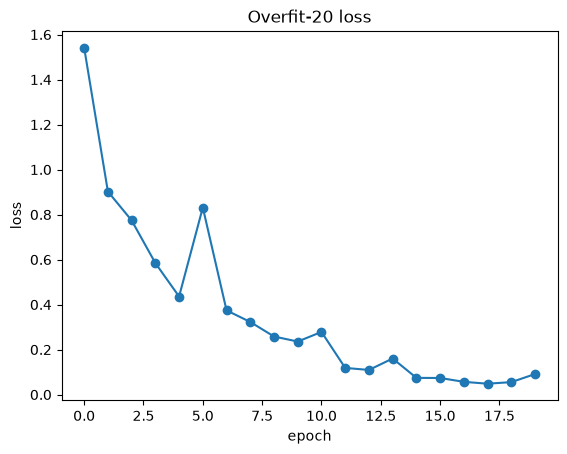

first loss: 1.541675591468811
last loss: 0.09149781465530396


In [53]:
plt.plot(overfit_losses, marker='o')
plt.title('Overfit-20 loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

print('first loss:', overfit_losses[0])
print('last loss:', overfit_losses[-1])

## Check Overfit-20 Predictions

The loss went down, but we also want to see whether the model is putting high probabilities on the correct labels for the 20 memorised images.

In [54]:
overfit_eval_loader = DataLoader(overfit_ds, batch_size=4, shuffle=False, num_workers=0)
overfit_preds = predict_loader(overfit_model, overfit_eval_loader)

display_cols = ['study_id', 'image_id']
for label in DISEASE_LABELS:
    name = safe_name(label)
    display_cols.extend([f'true_{name}', f'prob_{name}'])

overfit_preds[display_cols].head(10)

,study_id,image_id,true_Cardiomegaly,prob_Cardiomegaly,true_Atelectasis,prob_Atelectasis,true_Consolidation_Pneumonia,prob_Consolidation_Pneumonia,true_Pleural_Effusion,prob_Pleural_Effusion,true_Edema,prob_Edema,true_Pneumothorax,prob_Pneumothorax
0,10,10_IM-0002-2001.dcm,0.0,0.008175,0.0,0.000777,0.0,0.002024,0.0,0.001518,0.0,0.000578,0.0,0.000566
1,100,100_IM-0002-1001.dcm,0.0,0.002246,0.0,0.000115,0.0,0.000772,0.0,0.000672,0.0,0.000203,0.0,0.000232
2,1000,1000_IM-0003-1001.dcm,0.0,0.012098,1.0,0.998500,0.0,0.008939,0.0,0.008904,0.0,0.000295,0.0,0.000095
3,1000,1000_IM-0003-3001.dcm,0.0,0.010176,1.0,0.997972,0.0,0.010776,0.0,0.012918,0.0,0.000605,0.0,0.000215
4,1001,1001_IM-0004-1001.dcm,0.0,0.002158,0.0,0.000122,0.0,0.004439,0.0,0.004195,0.0,0.000337,0.0,0.000270
5,1002,1002_IM-0004-1001.dcm,0.0,0.011769,0.0,0.001338,0.0,0.001789,0.0,0.001570,0.0,0.000354,0.0,0.000319
6,1003,1003_IM-0005-2002.dcm,0.0,0.006078,0.0,0.002673,0.0,0.015953,0.0,0.015098,0.0,0.000686,0.0,0.000403
7,1005,1005_IM-0006-1001.dcm,0.0,0.001103,0.0,0.000460,0.0,0.002525,0.0,0.002130,0.0,0.000259,0.0,0.000258
8,1006,1006_IM-0007-1001.dcm,0.0,0.002307,0.0,0.000643,0.0,0.002509,0.0,0.001902,0.0,0.000488,0.0,0.000475
9,1007,1007_IM-0008-1001.dcm,0.0,0.004712,0.0,0.003182,0.0,0.003663,0.0,0.003076,0.0,0.000759,0.0,0.000576


## Full Fine-Tuning

Only run this after the overfit-20 loss clearly drops. On CPU this will be slow. Use Kaggle or Colab GPU for the real run.

In [55]:
RUN_FULL_TRAINING = True

RUN_FULL_TRAINING

True

In [56]:
if RUN_FULL_TRAINING:
    torch.manual_seed(42)
    model = build_model(num_outputs=len(DISEASE_LABELS)).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    best_model_state = None
    best_val_macro = -1
    history = []

    for epoch in range(1, 11):
        start = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)

        val_image_preds = predict_loader(model, val_loader)
        val_study_preds = to_study_level(val_image_preds)
        val_metrics = compute_metric_table(val_study_preds)
        val_macro = macro_auroc_supported(val_metrics)

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_macro_AUROC_supported_4': val_macro,
            'seconds': time.time() - start,
        })

        print(f'epoch {epoch:02d} train_loss={train_loss:.4f} val_macro={val_macro:.4f}')

        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, OUT_DIR / 'finetuned_densenet121_best.pt')

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUT_DIR / 'finetuned_train_history.csv', index=False)
    history_df
else:
    print('Full training skipped. Set RUN_FULL_TRAINING = True when you are ready.')

epoch 01 train_loss=1.1568 val_macro=0.8705
epoch 02 train_loss=0.8024 val_macro=0.8790
epoch 03 train_loss=0.6567 val_macro=0.8908
epoch 04 train_loss=0.5710 val_macro=0.8891
epoch 05 train_loss=0.4446 val_macro=0.8714
epoch 06 train_loss=0.3728 val_macro=0.8819
epoch 07 train_loss=0.3721 val_macro=0.8870
epoch 08 train_loss=0.2654 val_macro=0.8726
epoch 09 train_loss=0.2385 val_macro=0.8356
epoch 10 train_loss=0.1996 val_macro=0.8607


## Pick Thresholds On Validation

This chooses per-class thresholds using validation only. Do not tune thresholds on test.

In [57]:
def best_f1_threshold(y_true, y_prob):
    best_threshold = 0.5
    best_f1 = -1
    for threshold in np.linspace(0.05, 0.95, 91):
        y_pred = (y_prob >= threshold).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold
    return best_threshold, best_f1


if RUN_FULL_TRAINING:
    model.load_state_dict(torch.load(OUT_DIR / 'finetuned_densenet121_best.pt', map_location=device))
    val_image_preds = predict_loader(model, val_loader)
    val_study_preds = to_study_level(val_image_preds)

    threshold_rows = []
    for label in DISEASE_LABELS:
        name = safe_name(label)
        y_true = val_study_preds[f'true_{name}'].astype(int).values
        y_prob = val_study_preds[f'prob_{name}'].astype(float).values
        threshold, f1 = best_f1_threshold(y_true, y_prob)
        threshold_rows.append({'label': label, 'threshold': threshold, 'val_F1': f1})

    thresholds_df = pd.DataFrame(threshold_rows)
    thresholds_df.to_csv(OUT_DIR / 'val_thresholds.csv', index=False)
    thresholds_df
else:
    print('Threshold selection skipped until full training runs.')

C:\Users\rashe\AppData\Local\Temp\ipykernel_18472\285272759.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(OUT_DIR / 'finetuned_densen

## Test Evaluation At Study Level

Use the best checkpoint and evaluate once on test. This matches the baseline evaluation shape.

In [58]:
if RUN_FULL_TRAINING:
    model.load_state_dict(torch.load(OUT_DIR / 'finetuned_densenet121_best.pt', map_location=device,weights_only=True))
    test_image_preds = predict_loader(model, test_loader)
    test_study_preds = to_study_level(test_image_preds)
    test_metrics = compute_metric_table(test_study_preds)

    test_study_preds.to_csv(OUT_DIR / 'finetuned_test_predictions.csv', index=False)
    test_metrics.to_csv(OUT_DIR / 'finetuned_test_metrics.csv', index=False)

    print('macro AUROC on supported 4:', macro_auroc_supported(test_metrics))
    display(test_metrics)
else:
    print('Test evaluation skipped until full training runs.')

macro AUROC on supported 4: 0.8742620078070961


,label,test_positive_studies,AUROC,AP,note
0,Cardiomegaly,44,0.887576,0.421361,
1,Atelectasis,44,0.825862,0.407550,
2,Consolidation / Pneumonia,28,0.877531,0.212729,
3,Pleural Effusion,22,0.906078,0.530047,
4,Edema,2,0.771898,0.032033,data-limited
5,Pneumothorax,3,0.603291,0.010953,data-limited


## Compare Against Baseline

Run this after full fine-tuning creates `finetuned_test_metrics.csv`.

In [59]:
baseline_metrics_path = OUT_DIR / 'baseline_test_metrics.csv'
finetuned_metrics_path = OUT_DIR / 'finetuned_test_metrics.csv'

if baseline_metrics_path.exists() and finetuned_metrics_path.exists():
    baseline_metrics = pd.read_csv(baseline_metrics_path).assign(model='baseline')
    finetuned_metrics = pd.read_csv(finetuned_metrics_path).assign(model='fine-tuned')
    comparison = pd.concat([baseline_metrics, finetuned_metrics], ignore_index=True)
    display(comparison[['model', 'label', 'test_positive_studies', 'AUROC', 'AP', 'note']])
else:
    print('Comparison skipped. Need both baseline and fine-tuned metric files.')

,model,label,test_positive_studies,AUROC,AP,note
0,baseline,Cardiomegaly,44,0.896065,0.423952,NaN
1,baseline,Atelectasis,44,0.816475,0.305423,NaN
2,baseline,Consolidation / Pneumonia,28,0.895183,0.293812,NaN
3,baseline,Pleural Effusion,22,0.931129,0.705717,NaN
4,baseline,Edema,2,0.552920,0.168707,data-limited
5,baseline,Pneumothorax,3,0.329677,0.005801,data-limited
6,fine-tuned,Cardiomegaly,44,0.887576,0.421361,NaN
7,fine-tuned,Atelectasis,44,0.825862,0.407550,NaN
8,fine-tuned,Consolidation / Pneumonia,28,0.877531,0.212729,NaN
9,fine-tuned,Pleural Effusion,22,0.906078,0.530047,NaN


## What I Checked

- The model uses the same 6 disease outputs as the baseline.
- `pos_weight` is computed from train only.
- The overfit-20 check runs before full training.
- Overfit-20 loss dropped from 1.54 to 0.22, with the lowest loss around 0.049 in the local CPU run.
- The overfit-20 prediction table checks targets against predicted probabilities.
- Full training is guarded by `RUN_FULL_TRAINING`, so it cannot start by accident.
- Validation is used for model selection and thresholds.
- Test evaluation is study-level.
- Edema and Pneumothorax remain data-limited.